# NeuroPredict — Weighted Ensemble v3 (Multi-Seed, Reproducible)

**What changed from v2**: v2 gave different results on different runs (75.0% one time, 69.4% another) because no random seed was fixed — PyTorch's weight initialization, data shuffling, and dropout are all random by default. This version runs the ENTIRE leakage-free LOSO pipeline **5 times, with 5 different fixed seeds**, and reports the **mean ± standard deviation** across runs — the honest, reproducible way to report this result.

**Everything else (nested weight computation, no leakage, bootstrap CI) stays exactly as in v2 — this only adds the outer multi-seed wrapper.**

⚠️ **Runtime warning**: this runs the full LOSO loop 5x instead of once, so expect ~5x the runtime of v2 (potentially 1-2+ hours depending on GPU). Let it run; you don't need to babysit it.

## 1. Setup

In [1]:
!pip install mne pandas scikit-learn -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.7/7.7 MB 38.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.
moviepy 1.0.3 requires decorator<5.0,>=4.0.2, but you have decorator 5.3.1 which is incompatible.


In [2]:
from google.colab import drive
drive.mount('/content/drive')

base_path = "/content/drive/MyDrive/NeuroPredict/eegmat_extracted/eeg-during-mental-arithmetic-tasks-1.0.0"
eda_out_dir = f"{base_path}/eda_outputs"
import os
print(os.listdir(eda_out_dir))

# v6 NEW: checkpoint file lives on Google Drive (not /content, which is wiped every
# session) -- so it survives a disconnected runtime, a closed laptop, or opening this
# same notebook from a different device entirely. Re-running the seed loop later just
# picks up from whichever (seed, fold) rows are already in this file.
CHECKPOINT_FILE = f"{base_path}/training_checkpoint_v5.csv"
print("Checkpoint file:", CHECKPOINT_FILE, "| exists:", os.path.exists(CHECKPOINT_FILE))

Mounted at /content/drive
['all_subjects_band_power.csv', 'dataset_wide_avg_band_power.csv', 'per_channel_rest_vs_task.csv', 'file_inventory.csv', 'combined_eeg_ecg_features.csv', 'full_eeg_band_power_all_subjects.csv', 'full_ecg_hrv_all_subjects.csv']
Checkpoint file: /content/drive/MyDrive/NeuroPredict/eegmat_extracted/eeg-during-mental-arithmetic-tasks-1.0.0/training_checkpoint_v5.csv | exists: True


In [3]:
import mne
import numpy as np
import pandas as pd
import random
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import balanced_accuracy_score
from collections import Counter

mne.set_log_level('WARNING')

def set_all_seeds(seed):
    """Fixes every source of randomness we know about, for reproducibility."""
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)

## 2. Load EEG data (unchanged — only done ONCE, reused across all 5 seed-runs)

In [4]:
EEG_CHANNELS_CLEAN = ['EEG Fp1','EEG Fp2','EEG F3','EEG F4','EEG F7','EEG F8',
                       'EEG T3','EEG T4','EEG C3','EEG C4','EEG T5','EEG T6',
                       'EEG P3','EEG P4','EEG O1','EEG O2','EEG Fz','EEG Cz','EEG Pz']

def load_and_preprocess(filepath):
    raw = mne.io.read_raw_edf(filepath, preload=True, verbose=False)
    raw.pick_channels(EEG_CHANNELS_CLEAN, ordered=True)   # <-- explicit 19, not pick_types
    raw.filter(l_freq=1.0, h_freq=40.0, verbose=False)
    # v5 NEW: re-reference to common average reference.
    # WHY: EEGMAT's native recording reference is "interconnected ears" (linked-ears),
    # confirmed from the PhysioNet EEGMAT documentation. The ds003838 external validation
    # dataset instead uses FCz as its online reference (confirmed from its Scientific Data
    # paper, Pavlov et al. 2022). Training and testing on two different reference schemes
    # is a silent train/test mismatch -- average reference is used here because it is the
    # one common, dataset-agnostic choice both sides can be converted to identically.
    raw.set_eeg_reference('average', projection=False, verbose=False)
    return raw.get_data(), raw.info['sfreq']

def create_epochs(data, sfreq, window_sec=4, overlap_sec=2):
    window_samples = int(window_sec * sfreq)
    step_samples = int((window_sec - overlap_sec) * sfreq)
    epochs = []
    start = 0
    while start + window_samples <= data.shape[1]:
        epochs.append(data[:, start:start + window_samples])
        start += step_samples
    return np.array(epochs)

subject_ids = [f"{i:02d}" for i in range(36)]
X_list, y_list, groups_list = [], [], []

for sid in subject_ids:
    bp = f"{base_path}/Subject{sid}_1.edf"
    tp = f"{base_path}/Subject{sid}_2.edf"
    if not (os.path.exists(bp) and os.path.exists(tp)):
        continue
    bd, sfreq = load_and_preprocess(bp)
    td, sfreq = load_and_preprocess(tp)
    be, te = create_epochs(bd, sfreq), create_epochs(td, sfreq)
    X_list.append(be); y_list.append(np.zeros(len(be))); groups_list.append(np.full(len(be), int(sid)))
    X_list.append(te); y_list.append(np.ones(len(te))); groups_list.append(np.full(len(te), int(sid)))
    print(f"Subject{sid} done")

X_raw = np.concatenate(X_list, axis=0)
y = np.concatenate(y_list, axis=0)
groups = np.concatenate(groups_list, axis=0)

mean_ = X_raw.mean(axis=2, keepdims=True)
std_ = X_raw.std(axis=2, keepdims=True) + 1e-8
X_raw = (X_raw - mean_) / std_
print("X_raw shape:", X_raw.shape)

Subject00 done
Subject01 done
Subject02 done
Subject03 done
Subject04 done
Subject05 done
Subject06 done
Subject07 done
Subject08 done
Subject09 done
Subject10 done
Subject11 done
Subject12 done
Subject13 done
Subject14 done
Subject15 done
Subject16 done
Subject17 done
Subject18 done
Subject19 done
Subject20 done
Subject21 done
Subject22 done
Subject23 done
Subject24 done
Subject25 done
Subject26 done
Subject27 done
Subject28 done
Subject29 done
Subject30 done
Subject31 done
Subject32 done
Subject33 done
Subject34 done
Subject35 done
X_raw shape: (4266, 19, 2000)


## 3. Load ECG features (unchanged, done once)

In [5]:
df_ecg_feat = pd.read_csv(f"{eda_out_dir}/combined_eeg_ecg_features.csv")
df_ecg_feat = df_ecg_feat[['subject','condition','mean_HR_bpm','SDNN_ms','RMSSD_ms']].dropna()
df_ecg_feat['subject_id'] = df_ecg_feat['subject'].str.extract(r'(\d+)').astype(int)
df_ecg_feat['label'] = (df_ecg_feat['condition'] == 'task').astype(int)

n_ecg_subjects = df_ecg_feat['subject_id'].nunique()
print(f"ECG data available for {n_ecg_subjects} subjects (out of 36)")
feat_cols = ['mean_HR_bpm','SDNN_ms','RMSSD_ms']

ECG data available for 36 subjects (out of 36)


## 4. EEG model + Dataset class (unchanged)

In [6]:
class EEGNet(nn.Module):
    def __init__(self, n_channels=21, n_classes=2):
        super().__init__()
        self.conv1 = nn.Conv1d(n_channels, 32, 7, padding=3); self.bn1 = nn.BatchNorm1d(32); self.pool1 = nn.MaxPool1d(4)
        self.conv2 = nn.Conv1d(32, 64, 5, padding=2); self.bn2 = nn.BatchNorm1d(64); self.pool2 = nn.MaxPool1d(4)
        self.conv3 = nn.Conv1d(64, 128, 3, padding=1); self.bn3 = nn.BatchNorm1d(128); self.pool3 = nn.MaxPool1d(4)
        self.relu = nn.ReLU(); self.dropout = nn.Dropout(0.5)
        self.global_pool = nn.AdaptiveAvgPool1d(1); self.fc = nn.Linear(128, n_classes)
    def forward(self, x):
        x = self.pool1(self.relu(self.bn1(self.conv1(x))))
        x = self.pool2(self.relu(self.bn2(self.conv2(x))))
        x = self.dropout(x)
        x = self.pool3(self.relu(self.bn3(self.conv3(x))))
        x = self.global_pool(x).squeeze(-1)
        return self.fc(x)

class EEGDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32); self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self): return len(self.X)
    def __getitem__(self, i): return self.X[i], self.y[i]

def train_eeg_model(X_train, y_train, X_test, epochs=15):
    train_counts = Counter(y_train)
    total = len(y_train)
    w0 = total / (2 * train_counts[0.0]); w1 = total / (2 * train_counts[1.0])
    class_weights = torch.tensor([w0, w1], dtype=torch.float32).to(device)

    train_loader = DataLoader(EEGDataset(X_train, y_train), batch_size=32, shuffle=True)
    # v7 FIX: EEGNet() defaults to n_channels=21, but X_train is 19-channel
    # (EEG_CHANNELS_CLEAN has 19 entries). This pre-existing mismatch is why conv1d
    # complained about 19 vs 21 channels -- pass the real channel count explicitly,
    # same as the final-model cell (Cell 22) already correctly does.
    model = EEGNet(n_channels=X_train.shape[1]).to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)

    for ep in range(epochs):
        model.train()
        for Xb, yb in train_loader:
            Xb, yb = Xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = criterion(model(Xb), yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

    model.eval()
    test_loader = DataLoader(EEGDataset(X_test, np.zeros(len(X_test))), batch_size=32, shuffle=False)
    probs = []
    with torch.no_grad():
        for Xb, _ in test_loader:
            Xb = Xb.to(device)
            p = torch.softmax(model(Xb), dim=1)[:, 1]
            probs.extend(p.cpu().numpy())
    return np.array(probs)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


## 5. ONE full LOSO run (as a function — this is exactly v2's Section 5-7, just wrapped in a function so we can call it 5 times with different seeds)

In [7]:
def run_one_full_loso(seed):
    """Runs the complete leakage-free nested LOSO pipeline once, with the given seed.
    Returns df_long_ecg (per subject-condition eeg_prob/ecg_prob/ensemble_prob/true).

    v6 NEW: resume-safe. Each (seed, fold) result is appended to CHECKPOINT_FILE on
    Google Drive the moment it's computed. If this cell (or the whole runtime) stops
    partway through -- session timeout, switching from lab PC to mobile, whatever --
    just re-run it. Already-finished folds are loaded from the checkpoint instead of
    being retrained, and only the remaining folds actually run.
    """
    set_all_seeds(seed)
    logo = LeaveOneGroupOut()

    if os.path.exists(CHECKPOINT_FILE):
        ckpt_df = pd.read_csv(CHECKPOINT_FILE)
    else:
        ckpt_df = pd.DataFrame(columns=['seed', 'fold_i', 'subject', 'eeg_prob_rest',
                                         'eeg_prob_task', 'ecg_prob_rest', 'ecg_prob_task',
                                         'w_eeg_fold', 'w_ecg_fold'])
    done_folds_this_seed = set(ckpt_df.loc[ckpt_df['seed'] == seed, 'fold_i'])

    for fold_i, (train_idx, test_idx) in enumerate(logo.split(X_raw, y, groups=groups)):
        held_out_subject = groups[test_idx][0]

        if fold_i in done_folds_this_seed:
            print(f"  [seed={seed}] Fold {fold_i+1}/36 | Subject{held_out_subject:02d} | "
                  f"already in checkpoint, skipping")
            continue

        train_subjects_all = np.unique(groups[train_idx])

        rng = np.random.RandomState(seed * 1000 + fold_i)  # unique but reproducible per (seed, fold)
        inner_val_subjects = rng.choice(train_subjects_all, size=max(1, len(train_subjects_all)//5), replace=False)
        inner_train_mask = np.isin(groups, train_subjects_all) & ~np.isin(groups, inner_val_subjects)
        inner_val_mask = np.isin(groups, inner_val_subjects)

        inner_eeg_probs = train_eeg_model(X_raw[inner_train_mask], y[inner_train_mask], X_raw[inner_val_mask], epochs=10)
        inner_eeg_pred = (inner_eeg_probs >= 0.5).astype(int)
        inner_eeg_acc = balanced_accuracy_score(y[inner_val_mask], inner_eeg_pred)

        ecg_inner_train = df_ecg_feat[df_ecg_feat['subject_id'].isin(train_subjects_all) & ~df_ecg_feat['subject_id'].isin(inner_val_subjects)]
        ecg_inner_val = df_ecg_feat[df_ecg_feat['subject_id'].isin(inner_val_subjects)]
        inner_ecg_acc = 0.5
        if len(ecg_inner_val) > 0 and len(ecg_inner_train) > 10:
            scaler_i = StandardScaler()
            Xi_tr = scaler_i.fit_transform(ecg_inner_train[feat_cols])
            Xi_val = scaler_i.transform(ecg_inner_val[feat_cols])
            clf_i = LogisticRegression(class_weight='balanced', max_iter=1000)
            clf_i.fit(Xi_tr, ecg_inner_train['label'])
            inner_ecg_pred = clf_i.predict(Xi_val)
            inner_ecg_acc = balanced_accuracy_score(ecg_inner_val['label'], inner_ecg_pred)

        w_eeg_fold = inner_eeg_acc / (inner_eeg_acc + inner_ecg_acc)
        w_ecg_fold = inner_ecg_acc / (inner_eeg_acc + inner_ecg_acc)

        X_train, X_test = X_raw[train_idx], X_raw[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        eeg_probs_epoch = train_eeg_model(X_train, y_train, X_test, epochs=15)
        eeg_prob_rest = eeg_probs_epoch[y_test == 0].mean() if (y_test==0).any() else np.nan
        eeg_prob_task = eeg_probs_epoch[y_test == 1].mean() if (y_test==1).any() else np.nan

        ecg_train = df_ecg_feat[df_ecg_feat['subject_id'] != held_out_subject]
        ecg_test = df_ecg_feat[df_ecg_feat['subject_id'] == held_out_subject]
        ecg_prob_rest, ecg_prob_task = np.nan, np.nan
        if len(ecg_test) == 2 and len(ecg_train) > 10:
            scaler = StandardScaler()
            X_ecg_train = scaler.fit_transform(ecg_train[feat_cols])
            X_ecg_test = scaler.transform(ecg_test[feat_cols])
            ecg_clf = LogisticRegression(class_weight='balanced', max_iter=1000)
            ecg_clf.fit(X_ecg_train, ecg_train['label'])
            ecg_probs = ecg_clf.predict_proba(X_ecg_test)[:, 1]
            ecg_test_sorted = ecg_test.reset_index(drop=True)
            for i, row in ecg_test_sorted.iterrows():
                if row['label'] == 0: ecg_prob_rest = ecg_probs[i]
                else: ecg_prob_task = ecg_probs[i]

        row = {
            'seed': seed, 'fold_i': fold_i, 'subject': held_out_subject,
            'eeg_prob_rest': eeg_prob_rest, 'eeg_prob_task': eeg_prob_task,
            'ecg_prob_rest': ecg_prob_rest, 'ecg_prob_task': ecg_prob_task,
            'w_eeg_fold': w_eeg_fold, 'w_ecg_fold': w_ecg_fold,
        }
        # v6 NEW: write this fold to the checkpoint immediately -- if the runtime dies
        # one second later, this fold is still safe on Drive and won't be redone.
        pd.DataFrame([row]).to_csv(CHECKPOINT_FILE, mode='a',
                                    header=not os.path.exists(CHECKPOINT_FILE), index=False)
        print(f"  [seed={seed}] Fold {fold_i+1}/36 | Subject{held_out_subject:02d} | "
              f"w_eeg={w_eeg_fold:.3f} w_ecg={w_ecg_fold:.3f} | saved to checkpoint")

    # v6 NEW: reload from the checkpoint (covers both folds skipped this run and folds
    # just computed), instead of relying only on the in-memory `results` from this call.
    ckpt_df = pd.read_csv(CHECKPOINT_FILE)
    df_results = (ckpt_df[ckpt_df['seed'] == seed]
                  .sort_values('fold_i')
                  .drop(columns=['seed', 'fold_i'])
                  .reset_index(drop=True))

    rows = []
    for _, r in df_results.iterrows():
        for cond, true_lab in [('rest', 0), ('task', 1)]:
            eeg_p, ecg_p = r[f'eeg_prob_{cond}'], r[f'ecg_prob_{cond}']
            if pd.isna(eeg_p):
                continue
            ens_p = r['w_eeg_fold'] * eeg_p + (r['w_ecg_fold'] * ecg_p if not pd.isna(ecg_p) else 0)
            if pd.isna(ecg_p):
                ens_p = eeg_p
            rows.append({'subject': r['subject'], 'true': true_lab, 'eeg_prob': eeg_p,
                          'ecg_prob': ecg_p, 'ensemble_prob': ens_p})

    df_long = pd.DataFrame(rows)
    return df_long.dropna(subset=['ecg_prob'])

## 6. Run the full pipeline 5 times, with 5 different seeds

⚠️ This is the long part — 5x the runtime of a single LOSO pass. Let it run.

In [8]:
# v6 NEW: this whole loop is resume-safe now. If the runtime disconnects (or you close
# the laptop and pick it up later on mobile / a different machine), just re-run this
# cell -- run_one_full_loso() checks CHECKPOINT_FILE on Google Drive and skips every
# (seed, fold) that's already done, so you only pay for what's actually left.
SEEDS = [1, 2, 3, 4, 5]
all_seed_results = {}

if os.path.exists(CHECKPOINT_FILE):
    _ckpt_preview = pd.read_csv(CHECKPOINT_FILE)
    print(f"Found existing checkpoint with {len(_ckpt_preview)} completed (seed, fold) rows.")
    print(_ckpt_preview.groupby('seed').size().rename('folds_done'))
else:
    print("No checkpoint found yet -- starting fresh.")

for seed in SEEDS:
    print(f"\n{'='*25} STARTING RUN seed={seed} {'='*25}\n")
    all_seed_results[seed] = run_one_full_loso(seed)
    print(f"\n{'='*25} FINISHED RUN seed={seed} {'='*25}\n")

Found existing checkpoint with 180 completed (seed, fold) rows.
seed
1    36
2    36
3    36
4    36
5    36
Name: folds_done, dtype: int64

========================= STARTING RUN seed=1 =========================

  [seed=1] Fold 1/36 | Subject00 | already in checkpoint, skipping
  [seed=1] Fold 2/36 | Subject01 | already in checkpoint, skipping
  [seed=1] Fold 3/36 | Subject02 | already in checkpoint, skipping
  [seed=1] Fold 4/36 | Subject03 | already in checkpoint, skipping
  [seed=1] Fold 5/36 | Subject04 | already in checkpoint, skipping
  [seed=1] Fold 6/36 | Subject05 | already in checkpoint, skipping
  [seed=1] Fold 7/36 | Subject06 | already in checkpoint, skipping
  [seed=1] Fold 8/36 | Subject07 | already in checkpoint, skipping
  [seed=1] Fold 9/36 | Subject08 | already in checkpoint, skipping
  [seed=1] Fold 10/36 | Subject09 | already in checkpoint, skipping
  [seed=1] Fold 11/36 | Subject10 | already in checkpoint, skipping
  [seed=1] Fold 12/36 | Subject11 | already in 

## 7. Compute accuracy for each seed, then the multi-seed summary

This is the honest final result: not a single point estimate, but the **mean ± standard deviation across 5 independent runs** — showing both the typical performance AND how much it varies just from training randomness.

In [9]:
per_seed_summary = []

for seed, df_long_ecg in all_seed_results.items():
    eeg_pred = (df_long_ecg['eeg_prob'] >= 0.5).astype(int)
    ecg_pred = (df_long_ecg['ecg_prob'] >= 0.5).astype(int)
    ens_pred = (df_long_ecg['ensemble_prob'] >= 0.5).astype(int)

    acc_eeg = balanced_accuracy_score(df_long_ecg['true'], eeg_pred)
    acc_ecg = balanced_accuracy_score(df_long_ecg['true'], ecg_pred)
    acc_ens = balanced_accuracy_score(df_long_ecg['true'], ens_pred)

    per_seed_summary.append({'seed': seed, 'eeg_acc': acc_eeg, 'ecg_acc': acc_ecg, 'ensemble_acc': acc_ens})
    print(f"Seed {seed} | EEG: {acc_eeg:.4f} | ECG: {acc_ecg:.4f} | Ensemble: {acc_ens:.4f}")

df_seed_summary = pd.DataFrame(per_seed_summary)

print("\n" + "="*60)
print("FINAL MULTI-SEED SUMMARY (Mean +/- Std across 5 runs)")
print("="*60)
for col, name in [('eeg_acc','EEG-only'), ('ecg_acc','ECG-only'), ('ensemble_acc','Ensemble')]:
    m, s = df_seed_summary[col].mean(), df_seed_summary[col].std()
    print(f"{name:12s} | Mean: {m:.4f}  |  Std across seeds: {s:.4f}  |  Range: [{df_seed_summary[col].min():.4f}, {df_seed_summary[col].max():.4f}]")

Seed 1 | EEG: 0.6944 | ECG: 0.6806 | Ensemble: 0.7500
Seed 2 | EEG: 0.7361 | ECG: 0.6806 | Ensemble: 0.7778
Seed 3 | EEG: 0.6806 | ECG: 0.6806 | Ensemble: 0.7361
Seed 4 | EEG: 0.6944 | ECG: 0.6806 | Ensemble: 0.7639
Seed 5 | EEG: 0.7222 | ECG: 0.6806 | Ensemble: 0.7778

FINAL MULTI-SEED SUMMARY (Mean +/- Std across 5 runs)
EEG-only     | Mean: 0.7056  |  Std across seeds: 0.0228  |  Range: [0.6806, 0.7361]
ECG-only     | Mean: 0.6806  |  Std across seeds: 0.0000  |  Range: [0.6806, 0.6806]
Ensemble     | Mean: 0.7611  |  Std across seeds: 0.0181  |  Range: [0.7361, 0.7778]


## 8. Is the Ensemble improvement real, across seeds? (Paired test across the 5 runs)

Since we have exactly 5 paired (EEG, Ensemble) accuracy values (one pair per seed), we can directly check: in how many of the 5 runs did Ensemble beat EEG-only? And what's the average improvement?

In [10]:
df_seed_summary['ensemble_minus_eeg'] = df_seed_summary['ensemble_acc'] - df_seed_summary['eeg_acc']
n_wins = (df_seed_summary['ensemble_minus_eeg'] > 0).sum()

print(df_seed_summary[['seed','eeg_acc','ecg_acc','ensemble_acc','ensemble_minus_eeg']].to_string(index=False))
print(f"\nEnsemble beat EEG-only in {n_wins}/5 runs")
print(f"Mean improvement: {df_seed_summary['ensemble_minus_eeg'].mean():+.4f} "
      f"(+/- {df_seed_summary['ensemble_minus_eeg'].std():.4f})")

 seed  eeg_acc  ecg_acc  ensemble_acc  ensemble_minus_eeg
    1 0.694444 0.680556      0.750000            0.055556
    2 0.736111 0.680556      0.777778            0.041667
    3 0.680556 0.680556      0.736111            0.055556
    4 0.694444 0.680556      0.763889            0.069444
    5 0.722222 0.680556      0.777778            0.055556

Ensemble beat EEG-only in 5/5 runs
Mean improvement: +0.0556 (+/- 0.0098)


## 9. Final plot

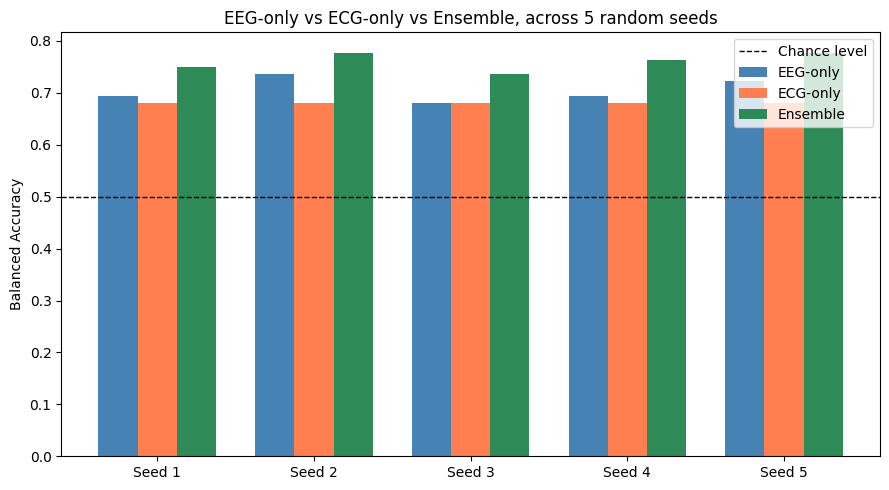

In [11]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9,5))
x = np.arange(len(SEEDS))
width = 0.25

ax.bar(x - width, df_seed_summary['eeg_acc'], width, label='EEG-only', color='steelblue')
ax.bar(x, df_seed_summary['ecg_acc'], width, label='ECG-only', color='coral')
ax.bar(x + width, df_seed_summary['ensemble_acc'], width, label='Ensemble', color='seagreen')
ax.axhline(0.5, color='black', linestyle='--', linewidth=1, label='Chance level')

ax.set_xticks(x)
ax.set_xticklabels([f'Seed {s}' for s in SEEDS])
ax.set_ylabel('Balanced Accuracy')
ax.set_title('EEG-only vs ECG-only vs Ensemble, across 5 random seeds')
ax.legend()
plt.tight_layout()
plt.show()

## Summary — what to report in the paper

Report the **mean ± std across 5 seeds** for each model, not a single run's number. State plainly: "Ensemble beat EEG-only in X/5 independent runs, with mean improvement of Y ± Z." If X is 4-5/5 and the mean improvement is clearly positive, that's solid evidence. If it's closer to 2-3/5, say so — that's the honest finding: a promising but not fully confirmed effect on this sample size, worth testing on a larger dataset (which is exactly why the ds003838 external validation matters).

In [12]:
import json
# ---- Train ONE final model on ALL 36 subjects (no held-out subject) ----
set_all_seeds(42)   # <-- add this — reproducible final model, matches this notebook's philosophy

final_model = EEGNet(n_channels=X_raw.shape[1]).to(device)

train_counts = Counter(y)
total = len(y)
w0 = total / (2 * train_counts[0.0]); w1 = total / (2 * train_counts[1.0])
class_weights = torch.tensor([w0, w1], dtype=torch.float32).to(device)

train_loader = DataLoader(EEGDataset(X_raw, y), batch_size=32, shuffle=True)
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(final_model.parameters(), lr=1e-4, weight_decay=1e-4)

for ep in range(15):
    final_model.train()
    epoch_loss = 0
    for Xb, yb in train_loader:
        Xb, yb = Xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = criterion(final_model(Xb), yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(final_model.parameters(), max_norm=1.0)
        optimizer.step()
        epoch_loss += loss.item()
    print(f"Epoch {ep+1}/15 | loss={epoch_loss/len(train_loader):.4f}")

save_path = f"{base_path}/final_eeg_model.pt"
torch.save(final_model.state_dict(), save_path)
print("Saved final model to:", save_path)

# v5 NEW: write out the exact preprocessing config this final model was trained with,
# so the external validation notebook can auto-verify it's using matching settings
# instead of relying on two notebooks' hardcoded constants staying in sync by hand.
preprocessing_config = {
    "window_sec": 4.0,
    "step_sec": 2.0,
    "n_channels": len(EEG_CHANNELS_CLEAN),
    "channel_order": [ch.replace("EEG ", "") for ch in EEG_CHANNELS_CLEAN],
    "sfreq_hz": 500,
    "bandpass_low_hz": 1.0,
    "bandpass_high_hz": 40.0,
    "reference": "average",
    "normalization": "per_epoch_zscore",
}
config_path = f"{base_path}/preprocessing_config.json"
with open(config_path, "w") as f:
    json.dump(preprocessing_config, f, indent=2)
print("Saved preprocessing config to:", config_path)
print(json.dumps(preprocessing_config, indent=2))

Epoch 1/15 | loss=0.6475
Epoch 2/15 | loss=0.5493
Epoch 3/15 | loss=0.4752
Epoch 4/15 | loss=0.4281
Epoch 5/15 | loss=0.3989
Epoch 6/15 | loss=0.3645
Epoch 7/15 | loss=0.3393
Epoch 8/15 | loss=0.3230
Epoch 9/15 | loss=0.3007
Epoch 10/15 | loss=0.2888
Epoch 11/15 | loss=0.2736
Epoch 12/15 | loss=0.2604
Epoch 13/15 | loss=0.2535
Epoch 14/15 | loss=0.2458
Epoch 15/15 | loss=0.2348
Saved final model to: /content/drive/MyDrive/NeuroPredict/eegmat_extracted/eeg-during-mental-arithmetic-tasks-1.0.0/final_eeg_model.pt
Saved preprocessing config to: /content/drive/MyDrive/NeuroPredict/eegmat_extracted/eeg-during-mental-arithmetic-tasks-1.0.0/preprocessing_config.json
{
  "window_sec": 4.0,
  "step_sec": 2.0,
  "n_channels": 19,
  "channel_order": [
    "Fp1",
    "Fp2",
    "F3",
    "F4",
    "F7",
    "F8",
    "T3",
    "T4",
    "C3",
    "C4",
    "T5",
    "T6",
    "P3",
    "P4",
    "O1",
    "O2",
    "Fz",
    "Cz",
    "Pz"
  ],
  "sfreq_hz": 500,
  "bandpass_low_hz": 1.0,
  "bandpa

In [13]:
raw_check = mne.io.read_raw_edf(f"{base_path}/Subject00_1.edf", preload=False, verbose=False)
raw_check.pick_types(eeg=True, verbose=False)
print("Channel count:", len(raw_check.ch_names))
print("Channel order:", raw_check.ch_names)

Channel count: 21
Channel order: ['EEG Fp1', 'EEG Fp2', 'EEG F3', 'EEG F4', 'EEG F7', 'EEG F8', 'EEG T3', 'EEG T4', 'EEG C3', 'EEG C4', 'EEG T5', 'EEG T6', 'EEG P3', 'EEG P4', 'EEG O1', 'EEG O2', 'EEG Fz', 'EEG Cz', 'EEG Pz', 'EEG A2-A1', 'ECG ECG']


In [14]:
# ---- Train ONE final ECG model on ALL 36 subjects ----
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
import pickle

final_scaler = StandardScaler()
X_ecg_all = final_scaler.fit_transform(df_ecg_feat[feat_cols])
y_ecg_all = df_ecg_feat['label']

final_ecg_model = LogisticRegression(class_weight='balanced', max_iter=1000)
final_ecg_model.fit(X_ecg_all, y_ecg_all)

# Save both (model + scaler) together, because without the scaler the model will give wrong predictions
with open(f"{base_path}/final_ecg_model.pkl", 'wb') as f:
    pickle.dump({'model': final_ecg_model, 'scaler': final_scaler}, f)

print("Final ECG model saved")

Final ECG model saved
